# SPLICE Demo

Decomposes geospatial embeddings into sparse nonnegative combinations of text concept embeddings using SPLICE.

Loads the alignment model from a checkpoint directory and concepts from a JSON file.

## Setup

In [1]:
import sys
import json
from pathlib import Path

In [2]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

In [3]:
REPO_ROOT = Path("..").resolve()
SPLICE_DIR = REPO_ROOT / "src" / "explainability" / "splice"
LOCATION_TEXT_ALIGNMENT_DIR = SPLICE_DIR / "location_text_alignment"

In [4]:
for p in [str(LOCATION_TEXT_ALIGNMENT_DIR), str(SPLICE_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

In [5]:
from model import SPLICE
from models.model import build_model

## Configuration

In [ ]:
MODEL_DIR = Path(
    "/path/to/location_text/model"
).expanduser()

In [7]:
CONCEPT_SET  = LOCATION_TEXT_ALIGNMENT_DIR / "concept_dictionaries" / "git10m_concept_dictionary.json"

In [ ]:
DENSE_GRID_CSV = Path("/path/to/dense/grid/").expanduser()

In [9]:
BATCH_SIZE  = 512
SUBSET_SIZE = 10_000
L1_PENALTY  = 0.175
PROMPT      = "An image of a {concept}"

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Load Alignment Model

In [11]:
ckpt = torch.load(MODEL_DIR / "best.pt", map_location=device)
args = ckpt["args"]

model = build_model(
    text_encoder=args["text_encoder"],
    location_encoder=args["location_encoder"],
    text_projection=args["text_projection"],
    shared_dim=args["shared_dim"],
    text_finetune_mode=args["text_finetune_mode"],
    loc_finetune_mode=args["loc_finetune_mode"],
    text_proj_hidden_layers=args["text_proj_hidden_layers"],
    text_proj_hidden_features=args["text_proj_hidden_features"],
    text_nonlinearity=args["text_nonlinearity"],
    precomputed_text_embeddings=False,
    precomputed_location_embeddings=False,
    device=device,
    lora_r=int(args["lora_rank"]),
    lora_last_n_layers=args["lora_layers"],
)
model.load_state_dict(ckpt["model"], strict=False)
model.eval()
print("Model loaded.")

/home/libe2152/miniconda3/envs/fai/lib/python3.12/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_

Model loaded.


/home/libe2152/projects/explainable-earth-embeddings/src/location_encoders/csp/main/module.py:98: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.linear.weight)


## Load Concepts

In [12]:
with open(CONCEPT_SET) as f:
    concepts = json.load(f)

In [13]:
prompted = [PROMPT.format(concept=c) for c in concepts]

In [14]:
with torch.no_grad():
    emb_concepts = torch.cat([
        model.text_model_predict(prompted[i : i + BATCH_SIZE])
        for i in range(0, len(prompted), BATCH_SIZE)
    ])

print(f"Loaded {len(concepts)} concepts, embeddings: {emb_concepts.shape}")

Loaded 1020 concepts, embeddings: torch.Size([1020, 256])


## Compute Location Embeddings

In [15]:
df = pd.read_csv(DENSE_GRID_CSV)
df = df.sample(SUBSET_SIZE, random_state=0).reset_index(drop=True)
latlons = torch.tensor(df[["lat", "lon"]].values, dtype=torch.float32).to(device)

with torch.no_grad():
    loc_embs = model.location_model_predict(latlons)

print(f"Location embeddings: {loc_embs.shape}")

Location embeddings: torch.Size([10000, 256])


## Build SPLICE Model

In [16]:
class _LocWrapper(torch.nn.Module):
    """Wraps the location encoder to match the SPLICE encode_image interface."""
    def __init__(self, enc):
        super().__init__()
        self.enc = enc

    def encode_image(self, x):
        return self.enc(x)

In [17]:
mean_emb  = loc_embs.mean(0)
dict_embs = F.normalize(emb_concepts - emb_concepts.mean(0), dim=1)


In [18]:
splice_model = SPLICE(
    image_mean=mean_emb,
    dictionary=dict_embs,
    clip=_LocWrapper(model.location_encoder).to(device),
    solver="admm",
    device=device,
    return_weights=True,
    return_cosine=True,
    l1_penalty=L1_PENALTY,
    text_mean=None,
)

Using ADMM solver...
With rho value 5.0


## Reconstruction Metrics

In [19]:
all_orig, all_weights, all_recon = [], [], []

In [20]:
with torch.no_grad():
    for i in tqdm(range(0, len(latlons), BATCH_SIZE)):
        raw = splice_model.clip.encode_image(latlons[i : i + BATCH_SIZE])
        orig_b = F.normalize(raw, dim=1)
        weights_b = splice_model.decompose(F.normalize(orig_b - splice_model.image_mean, dim=1))
        recon_b = splice_model.recompose_image(weights_b)
        all_orig.append(orig_b)
        all_weights.append(weights_b)
        all_recon.append(recon_b)

100%|██████████| 20/20 [00:04<00:00,  4.76it/s]


In [21]:
orig = torch.cat(all_orig)
weights = torch.cat(all_weights)
recon = torch.cat(all_recon)

In [22]:
mse = F.mse_loss(recon, orig).item()
cos_sim = (recon * orig).sum(dim=1).mean().item()
l0_mean = (weights > 0).float().sum(dim=1).mean().item()

In [23]:
print(
    f"mse: {mse:.6f}\n"
    f"cosine_similarity: {cos_sim:.4f}\n"
    f"mean_active_concepts_l0: {l0_mean:.1f}\n"
    f"num_concepts: {int(weights.shape[1])}\n"
    f"num_samples: {int(len(orig))}"
)

mse: 0.004365
cosine_similarity: 0.4413
mean_active_concepts_l0: 15.4
num_concepts: 1020
num_samples: 10000


## Concept Decompositions

In [24]:
colors = {
    "Paris":   "#3a86ff",
    "Sahara":  "#e76f51",
    "Siberia": "#588157",
    "Bali":    "#9b5de5",
}

In [25]:
# Replace with desired locations
locations = {
    "Paris":   (48.8584,   2.2945),
    "Sahara":  (22.2348,   7.9586),
    "Siberia": (61.5240, 105.3188),
    "Bali":    (-8.4095, 115.1889),
}

In [26]:
# Number of concepts displayed
TOP_K = 4

In [27]:
def _decompose_latlon(lat, lon):
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=device)
    with torch.no_grad():
        raw = splice_model.clip.encode_image(latlon)
        orig_b = F.normalize(raw, dim=1)
        w_b = splice_model.decompose(F.normalize(orig_b - splice_model.image_mean, dim=1))
    return w_b[0]

## Print Concept Decompositions

In [28]:
for name, (lat, lon) in locations.items():
    w = _decompose_latlon(lat, lon)
    top_k = [(c, v) for c, v in sorted(zip(concepts, w.tolist()), key=lambda x: -x[1]) if v > 0][:TOP_K]
    print(f"{name}:")
    for concept, val in top_k:
        print(f"  {concept}: {val:.4f}")
    print()

Paris:
  greenhouse: 0.0321
  light: 0.0271
  floor: 0.0085
  section: 0.0079

Sahara:
  mass: 0.0773
  camper: 0.0529
  olive: 0.0492
  downward: 0.0364

Siberia:
  north: 0.0287
  infrastructure: 0.0287
  damage: 0.0276
  lumber: 0.0261

Bali:
  end: 0.0520
  confluence: 0.0512
  clearing: 0.0462
  logo: 0.0400



## Visualize Concept Decompositions

In [29]:
loc_decompositions = {}
for name, (lat, lon) in locations.items():
    w = _decompose_latlon(lat, lon)
    pairs = [(c, v) for c, v in sorted(zip(concepts, w.tolist()), key=lambda x: -x[1]) if v > 0][:TOP_K]
    loc_decompositions[name] = pairs

all_vals = [v for pairs in loc_decompositions.values() for _, v in pairs]
xmax = max(all_vals) * 1.12 if all_vals else 1.0


def _wrap_label(c, max_len=10):
    if " " in c:
        return c.replace(" ", "\n", 1)
    if len(c) > max_len:
        return c[:max_len] + "-\n" + c[max_len:]
    return c


plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size":       14,
    "axes.titlesize":  16,
    "axes.labelsize":  14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 13,
})

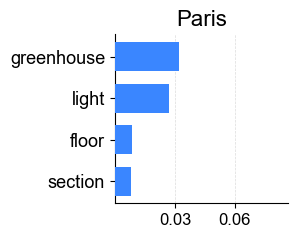

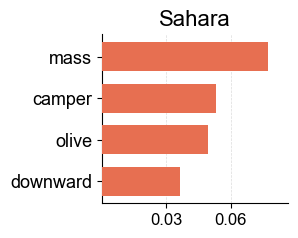

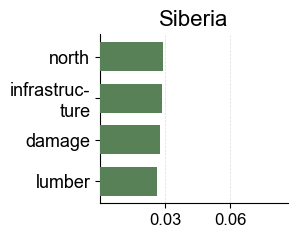

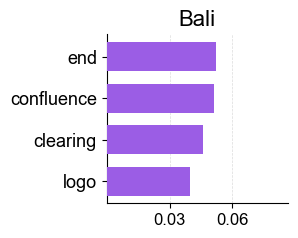

In [30]:
for name, (lat, lon) in locations.items():
    pairs = loc_decompositions[name]
    if not pairs:
        continue

    labels, vals = zip(*pairs)
    y = np.arange(len(vals))

    fig, ax = plt.subplots(figsize=(3.2, 2.6))
    ax.barh(y, vals, height=0.7, color=colors[name], edgecolor="none", zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([_wrap_label(c) for c in labels])
    ax.invert_yaxis()
    ax.set_xlim(0, xmax)
    ax.set_title(name)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3, prune="both"))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.grid(axis="x", linewidth=0.5, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
    plt.tight_layout()
    plt.show()